In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression


df=pd.read_csv('Forest.csv')

In [2]:
df.drop(['Unnamed: 0.1','Unnamed: 0'],axis=1,inplace=True)

In [3]:
df

,day,month,year,Temperature,RH,Ws,FFMC,DMC,DC,ISI,BUI,FWI,Region,Rain_new,Classes,Classes_fire,Classes_not fire
0,1,6,2012,29,57,18,65.7,3.4,7.6,1.3,3.4,0.5,0.0,0.0,not fire,0.0,1.0
1,2,6,2012,29,61,13,64.4,4.1,7.6,1.0,3.9,0.4,0.0,1.3,not fire,0.0,1.0
2,3,6,2012,26,82,22,47.1,2.5,7.1,0.3,2.7,0.1,0.0,13.1,not fire,0.0,1.0
3,4,6,2012,25,89,13,28.6,1.3,6.9,0.0,1.7,0.0,0.0,2.5,not fire,0.0,1.0
4,5,6,2012,27,77,16,64.8,3.0,14.2,1.2,3.9,0.5,0.0,0.0,not fire,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
238,26,9,2012,30,65,14,85.4,16.0,44.5,4.5,16.9,6.5,1.0,0.0,fire,1.0,0.0
239,27,9,2012,28,87,15,41.1,6.5,8.0,0.1,6.2,0.0,1.0,4.4,not fire,0.0,1.0
240,28,9,2012,27,87,29,45.9,3.5,7.9,0.4,3.4,0.2,1.0,0.5,not fire,0.0,1.0
241,29,9,2012,24,54,18,79.7,4.3,15.2,1.7,5.1,0.7,1.0,0.1,not fire,0.0,1.0


In [4]:
# drop the dependent and the indipendent features

df.drop(['day','month','year'],axis=1,inplace=True)

In [5]:
df.drop('Classes',axis=1,inplace=True)

In [6]:
df.corr()

,Temperature,RH,Ws,FFMC,DMC,DC,ISI,BUI,FWI,Region,Rain_new,Classes_fire,Classes_not fire
Temperature,1.000000,-0.651400,-0.284510,0.676568,0.485687,0.376284,0.603871,0.459789,0.566670,0.269555,-0.326492,0.516015,-0.516015
RH,-0.651400,1.000000,0.244048,-0.644873,-0.408519,-0.226941,-0.686667,-0.353841,-0.580957,-0.402682,0.222356,-0.432161,0.432161
Ws,-0.284510,0.244048,1.000000,-0.166548,-0.000721,0.079135,0.008532,0.031438,0.032368,-0.181160,0.171506,-0.069964,0.069964
FFMC,0.676568,-0.644873,-0.166548,1.000000,0.603608,0.507397,0.740007,0.592011,0.691132,0.222241,-0.543906,0.769492,-0.769492
DMC,0.485687,-0.408519,-0.000721,0.603608,1.000000,0.875925,0.680454,0.982248,0.875864,0.192089,-0.288773,0.585658,-0.585658
DC,0.376284,-0.226941,0.079135,0.507397,0.875925,1.000000,0.508643,0.941988,0.739521,-0.078734,-0.298023,0.511123,-0.511123
ISI,0.603871,-0.686667,0.008532,0.740007,0.680454,0.508643,1.000000,0.644093,0.922895,0.263197,-0.347484,0.735197,-0.735197
BUI,0.459789,-0.353841,0.031438,0.592011,0.982248,0.941988,0.644093,1.000000,0.857973,0.089408,-0.299852,0.586639,-0.586639
FWI,0.566670,-0.580957,0.032368,0.691132,0.875864,0.739521,0.922895,0.857973,1.000000,0.197102,-0.324422,0.719216,-0.719216
Region,0.269555,-0.402682,-0.181160,0.222241,0.192089,-0.078734,0.263197,0.089408,0.197102,1.000000,-0.040013,0.162347,-0.162347


In [7]:

X=df.drop('FWI',axis=1)

y=df['FWI']



In [8]:
# test tarin split 

from sklearn.model_selection import train_test_split

x_tain,x_test,y_tain,y_test=train_test_split(X,y,random_state=42,test_size=0.25)


In [9]:
# normaization
from sklearn.preprocessing import StandardScaler

scalor=StandardScaler()

x_train_scale=scalor.fit_transform(x_tain)



In [10]:
x_train_scale

array([[-0.84284248,  0.78307967,  1.29972026, ..., -0.33727373,
        -1.10431526,  1.10431526],
       [-0.30175842,  0.64950844, -0.59874754, ..., -0.29048728,
        -1.10431526,  1.10431526],
       [ 2.13311985, -2.08870172, -0.21905398, ..., -0.38406017,
         0.90553851, -0.90553851],
       ...,
       [-1.9250106 ,  0.9166509 ,  0.54033314, ...,  2.984564  ,
        -1.10431526,  1.10431526],
       [ 0.50986767, -0.21870454,  0.16063958, ..., -0.38406017,
         0.90553851, -0.90553851],
       [-0.57230045,  0.98343651,  2.05910739, ...,  0.45809587,
        -1.10431526,  1.10431526]], shape=(182, 12))

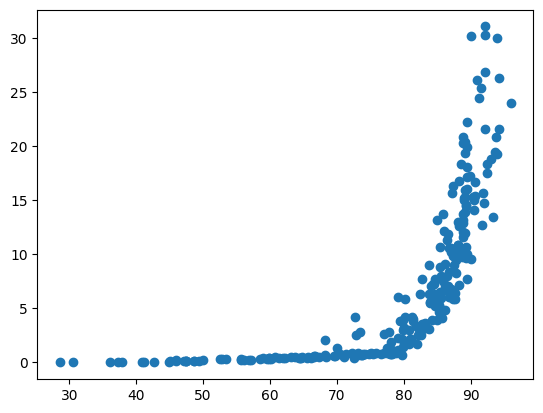

In [11]:
# we see the realtion between the input and the output how they vary
import matplotlib.pyplot as plt


plt.scatter(X['FFMC'],y)

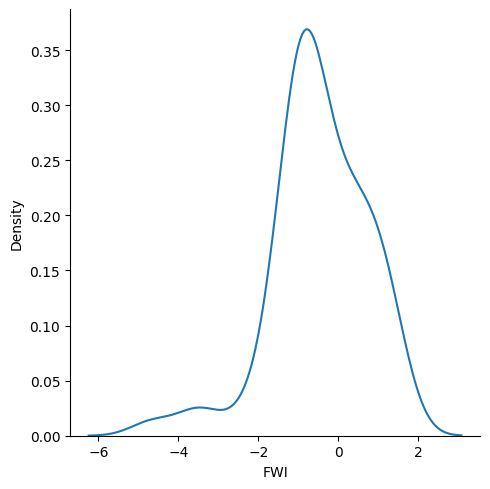

In [12]:

import seaborn as sns

x_test_scale=scalor.fit_transform(x_test)
regession=LinearRegression()

model=regession.fit(x_train_scale,y_tain)


y_predicted=model.predict(x_test_scale)


# plt.scatter(y_test,y_predicted)
resudial=y_test-y_predicted
sns.displot(resudial,kind='kde')


In [13]:
# we will check for the accuracy using the r square,and adjusted r square
from sklearn.metrics import mean_squared_error,r2_score

r2_score(y_test,y_predicted)
# mean_squared_error(y_test,y_predicted)

0.9631237047751696

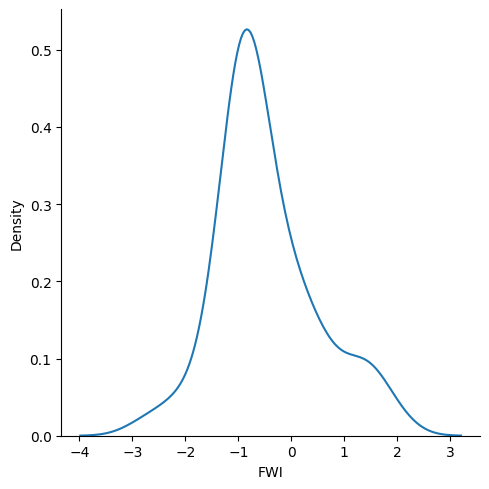

In [14]:
from sklearn.linear_model import Lasso,ElasticNet


regession=Lasso()

model=regession.fit(x_train_scale,y_tain)


y_predicted=model.predict(x_test_scale)


# plt.scatter(y_test,y_predicted)
resudial=y_test-y_predicted
sns.displot(resudial,kind='kde')



In [15]:
r2_score(y_test,y_predicted)

0.9751919605302054

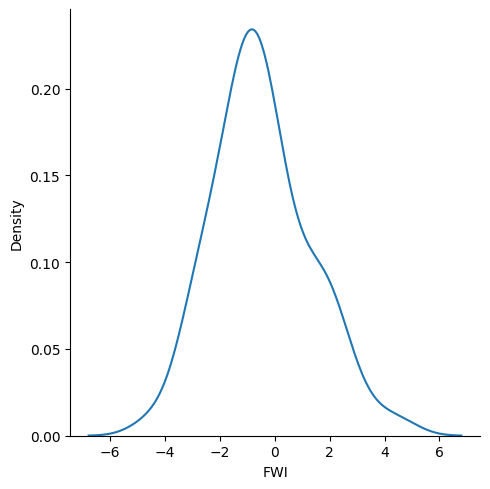

In [16]:
regession=ElasticNet()

model=regession.fit(x_train_scale,y_tain)


y_predicted=model.predict(x_test_scale)


# plt.scatter(y_test,y_predicted)
resudial=y_test-y_predicted
sns.displot(resudial,kind='kde')

In [17]:
r2_score(y_test,y_predicted)

0.9263010244643405

In [18]:
from sklearn.linear_model import Ridge


regession=Ridge()

model=regession.fit(x_train_scale,y_tain)

y_predicted=model.predict(x_test_scale)


r2_score(y_test,y_predicted)



0.9645089381995694

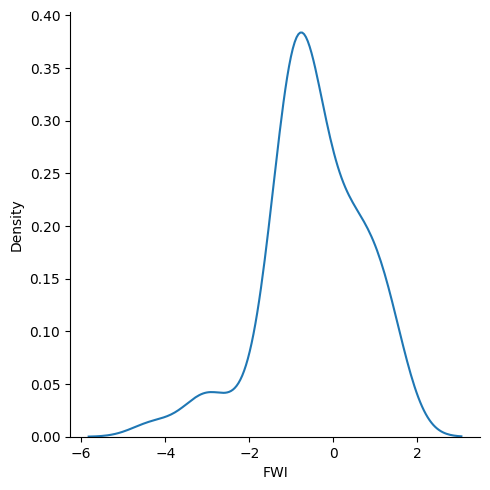

In [19]:
# assumption
resudial=y_test-y_predicted
sns.displot(resudial,kind='kde')


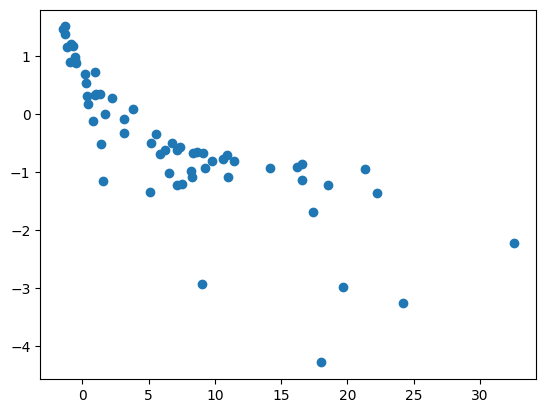

In [20]:
plt.scatter(y_predicted,resudial)

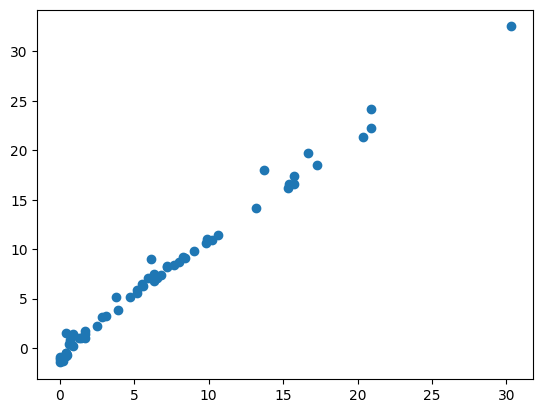

In [21]:
plt.scatter(y_test,y_predicted)

In [23]:
import pickle

pickle.dump(scalor,open('scalar.pkl','wb'))
pickle.dump(regession,open('Ridge.pkl','wb'))